<div class="alert alert-block alert-success">
    
### **Case Study** 📓: **Predicting Customer Churn**
    
#### [**Case Study Link**](https://docs.google.com/presentation/d/1NJ9MT6p1RRolUiFbDuwdS3kQHHF9VTdE/edit?slide=id.p1#slide=id.p1)


###  <font> **Import Libraries** </font>

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

###  <font> **Load Data** </font>

In [8]:
ccd = pd.read_csv("../data/Customer_Churn_Datasheet.csv")
customer_churn_data = ccd.copy()

<font> **Data Inspection** </font>

In [9]:
print(f"There are {ccd.shape[0]} rows and {ccd.shape[1]} columns")

There are 12923 rows and 21 columns


In [10]:
# Top 5 rows of the dataset
ccd.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# Data Info
ccd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12923 entries, 0 to 12922
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        12923 non-null  object 
 1   gender            12923 non-null  object 
 2   SeniorCitizen     12923 non-null  int64  
 3   Partner           12923 non-null  object 
 4   Dependents        12923 non-null  object 
 5   tenure            12923 non-null  int64  
 6   PhoneService      12923 non-null  object 
 7   MultipleLines     12923 non-null  object 
 8   InternetService   12923 non-null  object 
 9   OnlineSecurity    12923 non-null  object 
 10  OnlineBackup      12923 non-null  object 
 11  DeviceProtection  12923 non-null  object 
 12  TechSupport       12923 non-null  object 
 13  StreamingTV       12923 non-null  object 
 14  StreamingMovies   12923 non-null  object 
 15  Contract          12923 non-null  object 
 16  PaperlessBilling  12923 non-null  object

In [12]:
# Column Names
customer_churn_data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# Null Check
customer_churn_data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
# Duplicate Check
customer_churn_data.duplicated().sum()

np.int64(0)

In [15]:
# Data Description
ccd.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,12923.000000,12923.000000,12923.000000
mean,0.316180,34.272150,67.216926
std,0.465002,23.063998,29.633074
min,0.000000,0.000000,18.250000
25%,0.000000,13.000000,43.300000
50%,0.000000,33.000000,70.300000
75%,1.000000,55.000000,91.810000
max,1.000000,72.000000,119.990000


###  <font> **Data Cleaning & Preprocessing** </font>

 <font> **Drop ID Column** </font>

In [16]:
ccd.drop("customerID", axis=1, inplace=True)

<font> **Convert Mumeric Columns** </font>

In [17]:
ccd["TotalCharges"] = pd.to_numeric(
    ccd["TotalCharges"], errors="coerce"
)

<font> **Handling Missing/Empty/Null** </font>

In [18]:
ccd["TotalCharges"].fillna(ccd["TotalCharges"].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_3988\899504281.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ccd["TotalCharges"].fillna(ccd["TotalCharges"].median(), inplace=True)


<font> **Encode Target** </font>

In [19]:
ccd["Churn"] = ccd["Churn"].map({"Yes": 1, "No": 0})

In [20]:
ccd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12923 entries, 0 to 12922
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            12923 non-null  object 
 1   SeniorCitizen     12923 non-null  int64  
 2   Partner           12923 non-null  object 
 3   Dependents        12923 non-null  object 
 4   tenure            12923 non-null  int64  
 5   PhoneService      12923 non-null  object 
 6   MultipleLines     12923 non-null  object 
 7   InternetService   12923 non-null  object 
 8   OnlineSecurity    12923 non-null  object 
 9   OnlineBackup      12923 non-null  object 
 10  DeviceProtection  12923 non-null  object 
 11  TechSupport       12923 non-null  object 
 12  StreamingTV       12923 non-null  object 
 13  StreamingMovies   12923 non-null  object 
 14  Contract          12923 non-null  object 
 15  PaperlessBilling  12923 non-null  object 
 16  PaymentMethod     12923 non-null  object

<font> **Binary Encoding** </font>

In [21]:
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    ccd[col] = ccd[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})

In [22]:
ccd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12923 entries, 0 to 12922
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            12923 non-null  int64  
 1   SeniorCitizen     12923 non-null  int64  
 2   Partner           12923 non-null  int64  
 3   Dependents        12923 non-null  int64  
 4   tenure            12923 non-null  int64  
 5   PhoneService      12923 non-null  int64  
 6   MultipleLines     12923 non-null  object 
 7   InternetService   12923 non-null  object 
 8   OnlineSecurity    12923 non-null  object 
 9   OnlineBackup      12923 non-null  object 
 10  DeviceProtection  12923 non-null  object 
 11  TechSupport       12923 non-null  object 
 12  StreamingTV       12923 non-null  object 
 13  StreamingMovies   12923 non-null  object 
 14  Contract          12923 non-null  object 
 15  PaperlessBilling  12923 non-null  int64  
 16  PaymentMethod     12923 non-null  object

<font> **One-Hot Encoding** </font>

In [23]:
ccd = pd.get_dummies(ccd, drop_first=True)

<font> **Feature Scaling** </font>

In [24]:
scaler = StandardScaler()

In [25]:
# Data Description after scaling
ccd.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,12923.000000,12923.000000,12923.000000,12923.000000,12923.000000,12923.000000,12923.000000,12923.000000,12923.000000,12923.000000
mean,0.503366,0.316180,0.495009,0.385824,34.272150,0.719802,0.546390,67.216926,2411.854088,0.368877
std,0.500008,0.465002,0.499994,0.486808,23.063998,0.449113,0.497863,29.633074,2115.616353,0.482519
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,13.000000,0.000000,0.000000,43.300000,655.875000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,33.000000,1.000000,1.000000,70.300000,1760.025000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,55.000000,1.000000,1.000000,91.810000,3776.935000,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,119.990000,8684.800000,1.000000


###  <font> **Exploratory Data Analysis (EDA)** </font>

#### <font> **Univariate Analysis** </font>

In [26]:
ccd.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,True,False,False,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True


<font> **Pie Chart** </font>

In [27]:
ccd["Churn"].value_counts()

Churn
0    8156
1    4767
Name: count, dtype: int64

In [28]:
ccd["Churn"].value_counts(normalize=True).round(2)   

Churn
0    0.63
1    0.37
Name: proportion, dtype: float64

In [29]:
ccd["Churn"].mean().round(2)

np.float64(0.37)

Text(0.5, 1.0, 'Churn Distribution')

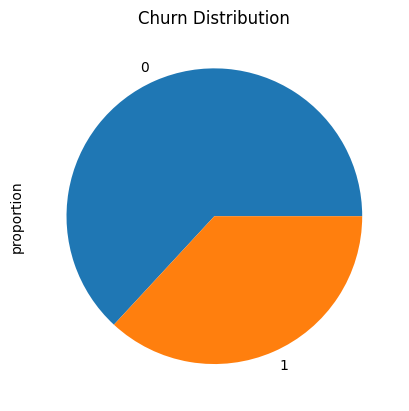

In [30]:
ccd["Churn"].value_counts(normalize=True).plot(kind="pie")
plt.title("Churn Distribution")

In [31]:
ccd.describe().round(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,12923.0,12923.00,12923.0,12923.00,12923.00,12923.00,12923.00,12923.00,12923.00,12923.00
mean,0.5,0.32,0.5,0.39,34.27,0.72,0.55,67.22,2411.85,0.37
std,0.5,0.47,0.5,0.49,23.06,0.45,0.50,29.63,2115.62,0.48
min,0.0,0.00,0.0,0.00,0.00,0.00,0.00,18.25,18.80,0.00
25%,0.0,0.00,0.0,0.00,13.00,0.00,0.00,43.30,655.88,0.00
50%,1.0,0.00,0.0,0.00,33.00,1.00,1.00,70.30,1760.02,0.00
75%,1.0,1.00,1.0,1.00,55.00,1.00,1.00,91.81,3776.94,1.00
max,1.0,1.00,1.0,1.00,72.00,1.00,1.00,119.99,8684.80,1.00


In [32]:
ccd.describe([0.85, 0.95, 0.99]).round(2) #percentiles

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,12923.0,12923.00,12923.0,12923.00,12923.00,12923.00,12923.00,12923.00,12923.00,12923.00
mean,0.5,0.32,0.5,0.39,34.27,0.72,0.55,67.22,2411.85,0.37
std,0.5,0.47,0.5,0.49,23.06,0.45,0.50,29.63,2115.62,0.48
min,0.0,0.00,0.0,0.00,0.00,0.00,0.00,18.25,18.80,0.00
50%,1.0,0.00,0.0,0.00,33.00,1.00,1.00,70.30,1760.02,0.00
85%,1.0,1.00,1.0,1.00,63.00,1.00,1.00,100.79,4973.01,1.00
95%,1.0,1.00,1.0,1.00,71.00,1.00,1.00,111.20,6692.55,1.00
99%,1.0,1.00,1.0,1.00,72.00,1.00,1.00,117.95,7901.97,1.00
max,1.0,1.00,1.0,1.00,72.00,1.00,1.00,119.99,8684.80,1.00


#### <font> **Bivariate Analysis** </font>

<Axes: >

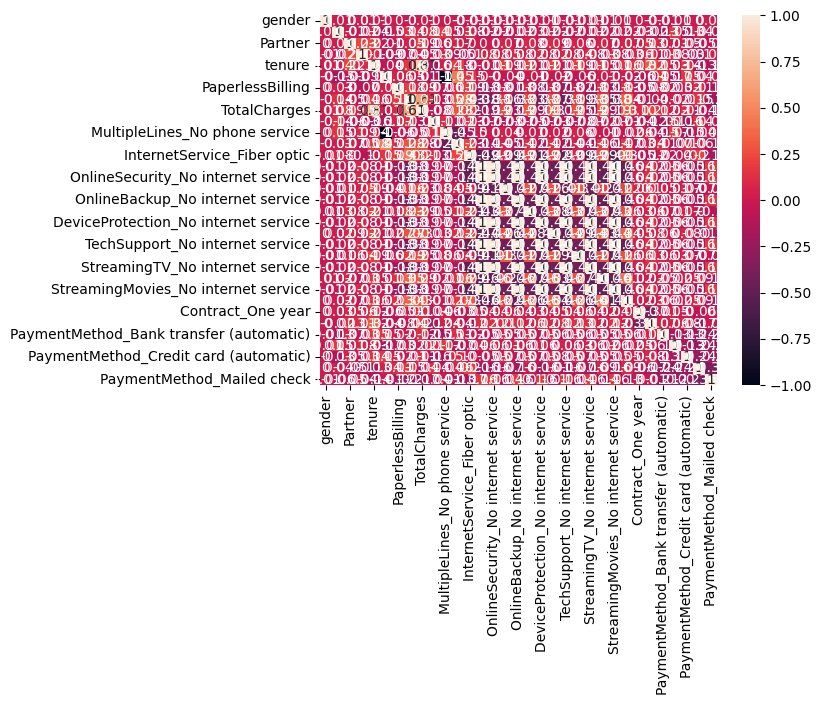

In [33]:
corr = ccd.corr(numeric_only=True).round(2)
sns.heatmap(corr, annot=True)

<font> **Categorical Values** </font>

In [34]:
cat_cols = ccd.select_dtypes(include="object").columns.tolist()
cat_cols

[]

<font> **Gender Distribution : Checking the Male and Female Count** </font>

In [54]:
ccd['gender'].value_counts()

gender
1    6505
0    6418
Name: count, dtype: int64

<Axes: xlabel='gender', ylabel='count'>

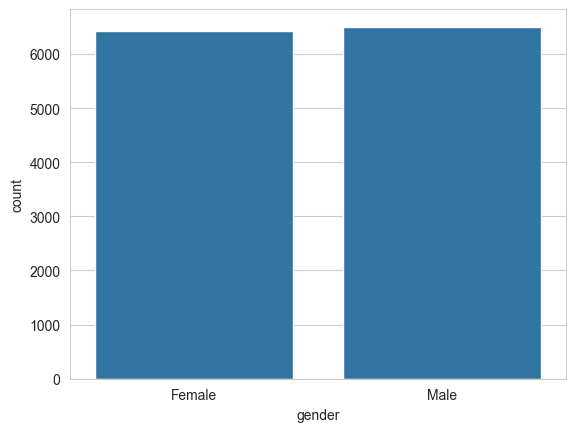

In [62]:
sns.set_style('whitegrid')
sns.countplot(x ='gender', data = customer_churn_data)

<font> **Checking the Contract: Types of Contracts with Counts** </font>

In [58]:
customer_churn_data["Contract"].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

<Axes: xlabel='Contract', ylabel='count'>

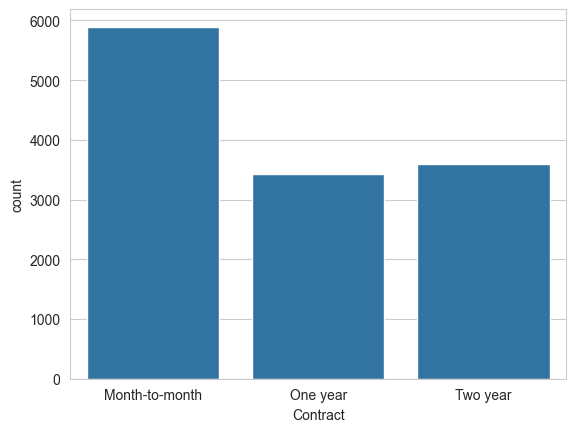

In [59]:
sns.set_style('whitegrid')
sns.countplot(x ='Contract', data = customer_churn_data)

<font> **Checking Payment Methods: Types & Counts** </font>

In [60]:
customer_churn_data['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)', 'Bank transfer', 'Credit card'],
      dtype=object)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)'),
  Text(4, 0, 'Bank transfer'),
  Text(5, 0, 'Credit card')])

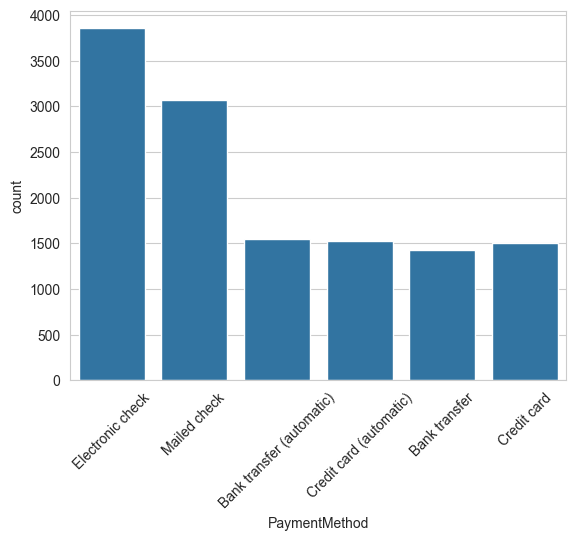

In [61]:
sns.set_style('whitegrid')
sns.countplot(x ='PaymentMethod', data = customer_churn_data)
plt.xticks(rotation=45)

<font>**Checking the Churn Counts** </font>

In [63]:
customer_churn_data['Churn'].unique()

array(['No', 'Yes'], dtype=object)

<Axes: xlabel='Churn', ylabel='count'>

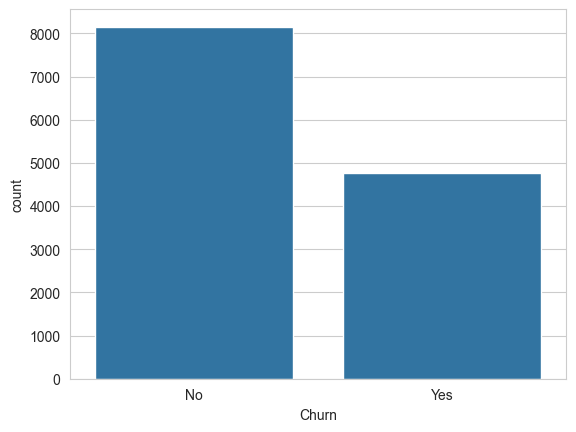

In [64]:
sns.set_style('whitegrid')
sns.countplot(x ='Churn', data = customer_churn_data)

<font> **Checking for the Relationship between the Total Charges & Churn ( if the Charges has to do anything with Churn or not)** </font>

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


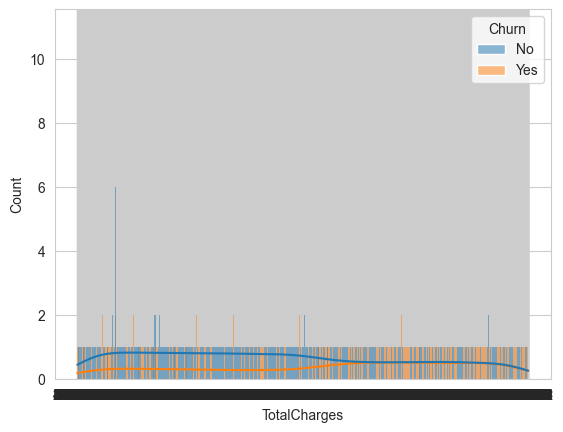

In [65]:
sns.histplot(data=customer_churn_data, x='TotalCharges', hue='Churn', kde=True)
plt.show()

<font> **Checking for the Relationship between the Total Charges & Gender** </font>

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


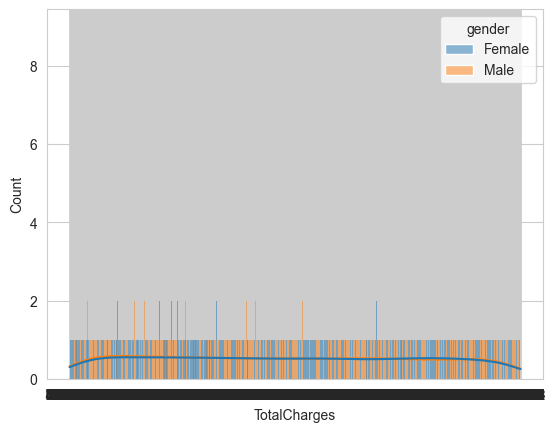

In [66]:
sns.histplot(data=customer_churn_data, x='TotalCharges', hue='gender', kde=True)
plt.show()

<font> **Dropping the Columns** </font>

In [67]:
customer_churn_data_updated = customer_churn_data.drop(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'], axis=1)

In [68]:
customer_churn_data_updated.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
0,0,1,29.85,29.85,No
1,0,34,56.95,1889.5,No
2,0,2,53.85,108.15,Yes
3,0,45,42.30,1840.75,No
4,0,2,70.70,151.65,Yes


<font> **Churn Distribution** </font>

<Axes: xlabel='Churn', ylabel='count'>

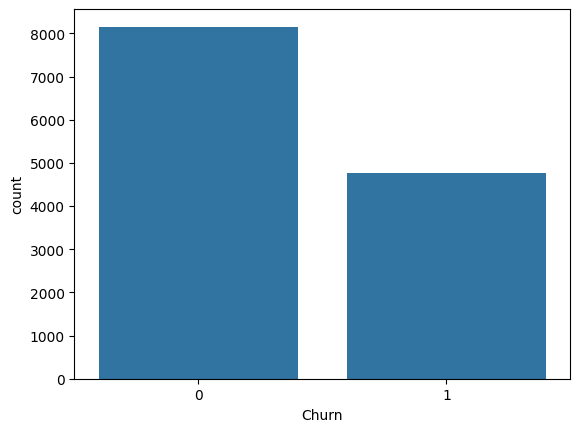

In [35]:
sns.countplot(x="Churn", data=ccd)

<font> **Churn by Contract Type** </font>

<Axes: xlabel='Contract_Two year', ylabel='count'>

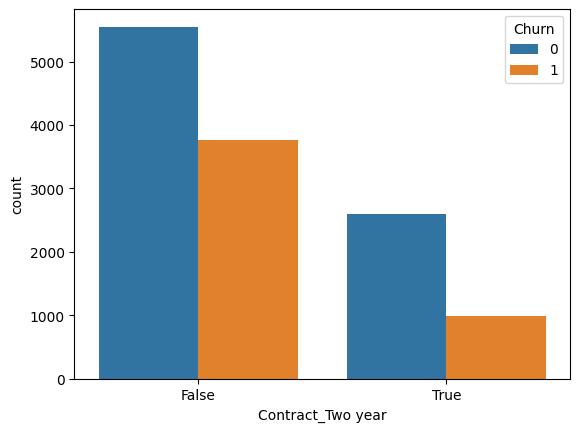

In [36]:
sns.countplot(x="Contract_Two year", hue="Churn", data=ccd)

<font> **Churn by Tenure** </font>

<Axes: xlabel='tenure', ylabel='Count'>

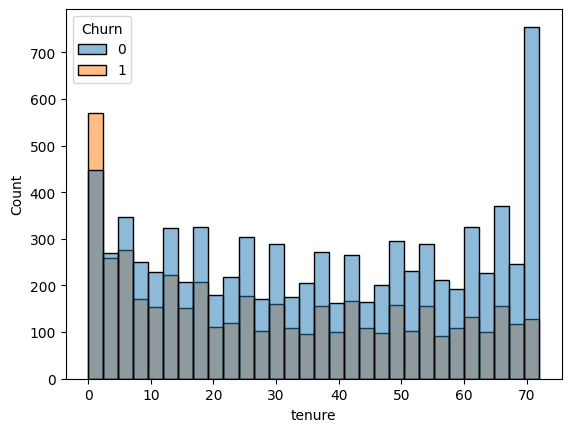

In [37]:
sns.histplot(data=ccd, x="tenure", hue="Churn", bins=30)

<font> **Churn by Internet Service** </font>

<Axes: xlabel='InternetService_Fiber optic', ylabel='count'>

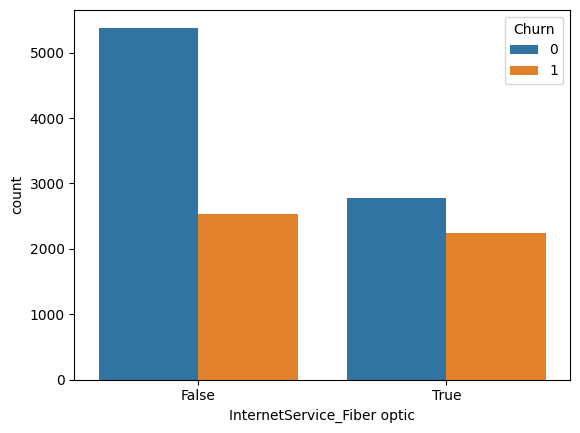

In [38]:
sns.countplot(x="InternetService_Fiber optic", hue="Churn", data=ccd)

####  <font> **Train-Test Split** </font>

In [39]:
X = ccd.drop("Churn", axis=1)
y = ccd["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

####  <font> **Model Training** </font>

<font> **Logistic Regression (Baseline)** </font>

In [40]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

<font> **Random Forest** </font>

In [41]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

<font> **Gradient Boosting** </font>

In [42]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

### <font> **Evaluation Metrics** </font>

In [43]:
def evaluate_model(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred))

In [44]:
evaluate_model(lr)

              precision    recall  f1-score   support

           0       0.71      0.81      0.76      1631
           1       0.57      0.42      0.49       954

    accuracy                           0.67      2585
   macro avg       0.64      0.62      0.62      2585
weighted avg       0.66      0.67      0.66      2585

Confusion Matrix:
 [[1329  302]
 [ 549  405]]
ROC AUC Score: 0.619682912439411


In [45]:
evaluate_model(rf)

              precision    recall  f1-score   support

           0       0.71      0.80      0.76      1631
           1       0.57      0.44      0.50       954

    accuracy                           0.67      2585
   macro avg       0.64      0.62      0.63      2585
weighted avg       0.66      0.67      0.66      2585

Confusion Matrix:
 [[1312  319]
 [ 530  424]]
ROC AUC Score: 0.6244294570474828


In [46]:
evaluate_model(gb)

              precision    recall  f1-score   support

           0       0.71      0.82      0.76      1631
           1       0.58      0.42      0.49       954

    accuracy                           0.67      2585
   macro avg       0.64      0.62      0.63      2585
weighted avg       0.66      0.67      0.66      2585

Confusion Matrix:
 [[1340  291]
 [ 551  403]]
ROC AUC Score: 0.6220068587264311


### <font> **Cost-Based Evaluation** </font>

FP (Predict churn but customer stays) → marketing cost <br>
FN (Predict stay but customer churn) → revenue loss

In [47]:
FP_cost = 10
FN_cost = 100

def calculate_cost(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    total_cost = FP * FP_cost + FN * FN_cost
    return total_cost

In [48]:
print("x_train: ", X_train.shape)
print("y_train: ", y_train.shape)


print("\n")

print("x_test: ", X_test.shape)
print("y_test: ", y_test.shape)

display(X_train.head())
display(y.head())

x_train:  (10338, 32)
y_train:  (10338,)


x_test:  (2585, 32)
y_test:  (2585,)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
11895,1,1,0,1,6,1,1,95.33,571.98,False,...,False,False,True,True,False,False,False,False,False,True
11152,1,0,1,1,49,1,1,74.75,3662.75,False,...,True,False,False,False,False,False,False,False,True,False
2668,1,0,0,1,1,1,0,19.75,19.75,False,...,False,True,False,False,False,False,False,False,False,True
6940,0,0,1,1,72,0,0,55.65,3880.05,True,...,False,False,True,False,True,False,False,True,False,False
12015,0,1,0,0,63,0,1,72.77,4584.51,True,...,True,False,True,True,False,False,False,False,True,False


0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [49]:
y.mean()

np.float64(0.3688771956975934)